In [9]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [10]:
# ── Configuración de Sujeto ───────────────────────────────────
SUBJECT = "S07"

# ── Diccionario de Rutas ──────────────────────────────────────
from pathlib import Path
BASE_DIR = Path("../../datasets/raw/myotensor_proto")

DATASETS = {
    "S02": {
        "csv": BASE_DIR / "S02" / "session_20260523_183340.csv",
        "meta": BASE_DIR / "S02" / "session_20260523_183340_metadata.json"
    },
    "S07": {
        "csv": BASE_DIR / "S07" / "session_20260426_222602.csv",
        "meta": BASE_DIR / "S07" / "session_20260426_222602_metadata.json"
    },
    "S08": {
        "csv": BASE_DIR / "S08" / "session_20260515_193936.csv",
        "meta": BASE_DIR / "S08" / "session_20260515_193936_metadata.json"
    },
    "S09": {
        "csv": BASE_DIR / "S09" / "session_20260515_195516.csv",
        "meta": BASE_DIR / "S09" / "session_20260515_195516_metadata.json"
    },
    "S10": {
        "csv": BASE_DIR / "S10" / "session_20260515_221119.csv",
        "meta": BASE_DIR / "S10" / "session_20260515_221119_metadata.json"
    },
    "S11": {
        "csv": BASE_DIR / "S11" / "session_20260515_222718.csv",
        "meta": BASE_DIR / "S11" / "session_20260515_222718_metadata.json"
    },
    "S12": {
        "csv": BASE_DIR / "S12" / "session_20260515_224208.csv",
        "meta": BASE_DIR / "S12" / "session_20260515_224208_metadata.json"
    },
    "S13": {
        "csv": BASE_DIR / "S13" / "session_20260515_225044.csv",
        "meta": BASE_DIR / "S13" / "session_20260515_225044_metadata.json"
    },
    "S14": {
        "csv": BASE_DIR / "S14" / "session_20260515_230336.csv",
        "meta": BASE_DIR / "S14" / "session_20260515_230336_metadata.json"
    },
    "S15": {
        "csv": BASE_DIR / "S15" / "session_20260515_231513.csv",
        "meta": BASE_DIR / "S15" / "session_20260515_231513_metadata.json"
    }
}

print(f"[*] Sujeto activo: {SUBJECT}")


[*] Sujeto activo: S07


In [11]:
# csv_path  = DATA_DIR / "session_20260515_222718.csv"
# meta_path = DATA_DIR / "session_20260515_222718_metadata.json"

csv_path = DATASETS[SUBJECT]["csv"]
meta_path = DATASETS[SUBJECT]["meta"]

In [12]:
# ── Metadata ───────────────────────────────────────────────────
with open(meta_path) as f:
    meta = json.load(f)
print(json.dumps(meta, indent=2, ensure_ascii=False))

# ── Dataset ────────────────────────────────────────────────────
df = pd.read_csv(csv_path)
df = df.sort_values("timestamp_us").reset_index(drop=True)
df['time_s'] = (df['timestamp_us'] - df['timestamp_us'].iloc[0]) / 1e6

print(f"\nForma: {df.shape}")
print(f"Duración (por timestamp): {df['time_s'].iloc[-1]:.2f}s")
print(f"Duración (por muestras):  {len(df)/1000:.2f}s")
df.head()

{
  "subject_id": "Sebe",
  "age": 23,
  "gender": "m",
  "laterality": "r",
  "forearm_circumference_cm": 26.0,
  "muscle": "fcpd",
  "date": "2026-04-26T22:26:02.673994",
  "fs_hz": 1000,
  "total_samples": 242160,
  "duration_s": 242.16,
  "gestures": [
    "palma",
    "puno",
    "paz"
  ],
  "gesture_ids": {
    "palma": 1,
    "puno": 2,
    "paz": 3
  },
  "n_sets": 10,
  "gesture_duration_s": 5.0,
  "rest_duration_s": 3.0,
  "prep_duration_s": 2.0,
  "randomized_order": true,
  "calibration": {
    "noise_mean": -2.912220229822397,
    "noise_std": 76.19257013736187,
    "onset_threshold_v": 225.6654901822632,
    "mvc_voltage_v": 172.64658021897253,
    "noise_samples": 5000,
    "mvc_samples": 3040
  },
  "onset_config": {
    "rms_window_ms": 100,
    "threshold_factor": 3.0,
    "min_active_ms": 200
  },
  "csv_file": "session_20260426_222602.csv"
}

Forma: (242160, 9)
Duración (por timestamp): 242.32s
Duración (por muestras):  242.16s


,timestamp_us,filtered,emg_norm,stimulus,repetition_id,restimulus,valid_flag,re_repetition_id,time_s
0,317594101,-19.3998,-0.112367,0,1,0,1,0,0.000
1,317595101,-14.6726,-0.084986,0,1,0,1,0,0.001
2,317596101,6.1357,0.035539,0,1,0,1,0,0.002
3,317597101,19.9707,0.115674,0,1,0,1,0,0.003
4,317598101,17.8823,0.103577,0,1,0,1,0,0.004


## 1 — Calidad de adquisición
Analizamos los intervalos entre timestamps para detectar gaps (paquetes UDP perdidos).

=== Calidad de adquisición ===
  Muestras grabadas:        242,160
  Intervalo medio:           1000.7 µs  (target: 1000 µs)
  Std intervalo:              162.6 µs
  Fs efectiva:                999.3 Hz
  Gaps detectados (>1.5ms):       4
  Muestras perdidas (est.):     159
  Pérdida:                     0.07%

  Top 10 gaps más grandes:
    41.0ms en t=96.04s
    41.0ms en t=96.88s
    41.0ms en t=96.32s
    41.0ms en t=97.72s


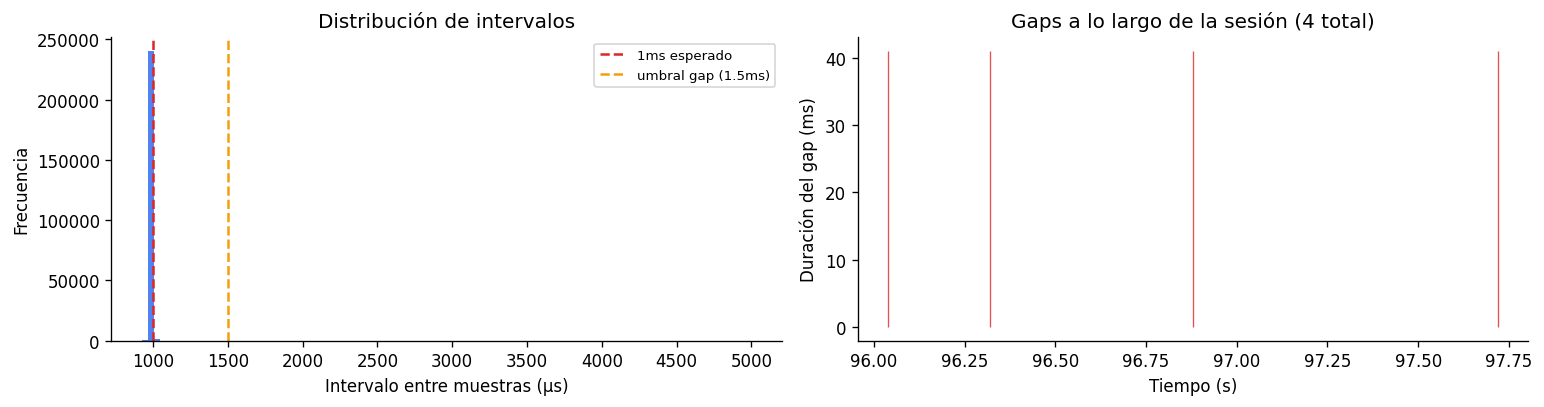

In [13]:
dt_us = df['timestamp_us'].diff().dropna()   # intervalos en µs
expected_us = 1000                            # 1ms @ 1kHz
gap_threshold_us = 1500                      # >1.5ms → muestra perdida

gaps = dt_us[dt_us > gap_threshold_us]
missing_est = int((gaps - expected_us).sum() / expected_us)
fs_efectiva = 1e6 / dt_us.mean()

print("=== Calidad de adquisición ===")
print(f"  Muestras grabadas:        {len(df):>7,}")
print(f"  Intervalo medio:          {dt_us.mean():>7.1f} µs  (target: {expected_us} µs)")
print(f"  Std intervalo:            {dt_us.std():>7.1f} µs")
print(f"  Fs efectiva:              {fs_efectiva:>7.1f} Hz")
print(f"  Gaps detectados (>{gap_threshold_us/1000:.1f}ms): {len(gaps):>7,}")
print(f"  Muestras perdidas (est.): {missing_est:>7,}")
print(f"  Pérdida:                  {missing_est/(len(df)+missing_est)*100:>7.2f}%")

print("\n  Top 10 gaps más grandes:")
for idx in gaps.nlargest(10).index:
    print(f"    {dt_us[idx]/1000:.1f}ms en t={df.loc[idx,'time_s']:.2f}s")

# ── Histograma de intervalos ───────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.5))

# Todos los intervalos
ax1.hist(dt_us.clip(upper=5000), bins=100, color='#2563eb', alpha=0.8, edgecolor='none')
ax1.axvline(expected_us, color='#dc2626', lw=1.5, ls='--', label='1ms esperado')
ax1.axvline(gap_threshold_us, color='#f59e0b', lw=1.5, ls='--', label=f'umbral gap ({gap_threshold_us/1000:.1f}ms)')
ax1.set_xlabel('Intervalo entre muestras (µs)')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de intervalos')
ax1.legend(fontsize=8)

# Gaps en el tiempo
ax2.vlines(df.loc[gaps.index, 'time_s'], 0, gaps.values / 1000,
           color='#dc2626', lw=0.8, alpha=0.8)
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Duración del gap (ms)')
ax2.set_title(f'Gaps a lo largo de la sesión ({len(gaps)} total)')

plt.tight_layout()
plt.show()

## 2 — Distribución de muestras por gesto

=== Muestras por gesto (stimulus) ===
  0 — Reposo  : 90,880 muestras  (90.9s)
  1 — Palma   : 50,600 muestras  (50.6s)
  2 — Puño    : 50,360 muestras  (50.4s)
  3 — Paz     : 50,320 muestras  (50.3s)

=== Muestras por gesto (restimulus) ===
  0 — Reposo  : 77,695 muestras  (77.7s)
  1 — Palma   : 54,427 muestras  (54.4s)
  2 — Puño    : 56,398 muestras  (56.4s)
  3 — Paz     : 53,640 muestras  (53.6s)


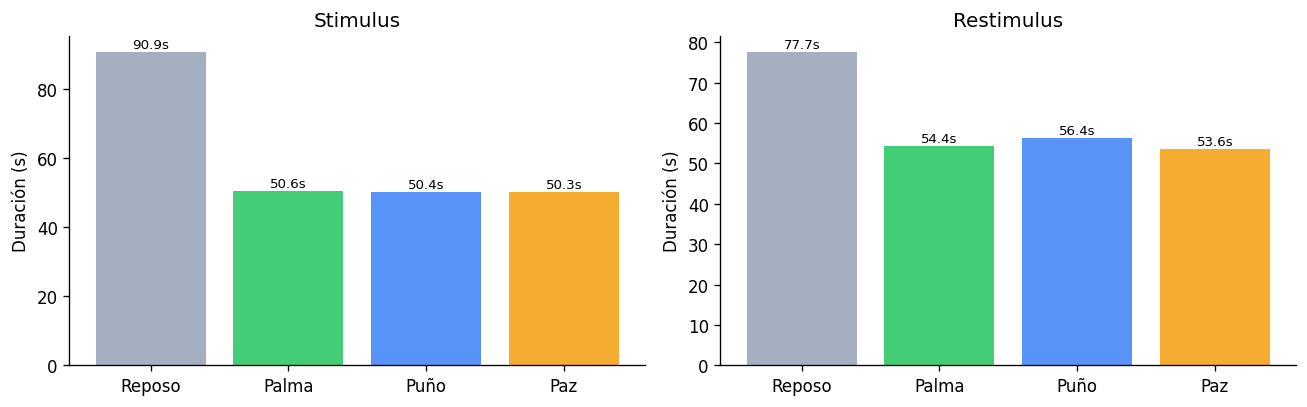

In [14]:
STIM_NAMES  = {0: 'Reposo', 1: 'Palma', 2: 'Puño', 3: 'Paz'}
STIM_COLORS = {0: '#94a3b8', 1: '#22c55e', 2: '#3b82f6', 3: '#f59e0b'}

print("=== Muestras por gesto (stimulus) ===")
for sid in sorted(df['stimulus'].unique()):
    n = (df['stimulus'] == sid).sum()
    dur = n / 1000
    print(f"  {sid} — {STIM_NAMES[sid]:<8}: {n:>6,} muestras  ({dur:.1f}s)")

print("\n=== Muestras por gesto (restimulus) ===")
for sid in sorted(df['restimulus'].unique()):
    n = (df['restimulus'] == sid).sum()
    print(f"  {sid} — {STIM_NAMES.get(sid,'Reposo'):<8}: {n:>6,} muestras  ({n/1000:.1f}s)")

# Barras
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, col, title in zip(axes, ['stimulus', 'restimulus'], ['Stimulus', 'Restimulus']):
    counts = df[col].value_counts().sort_index()
    bars = ax.bar(
        [STIM_NAMES[i] for i in counts.index],
        counts.values / 1000,
        color=[STIM_COLORS[i] for i in counts.index],
        edgecolor='none', alpha=0.85
    )
    ax.set_ylabel('Duración (s)')
    ax.set_title(title)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{v/1000:.1f}s', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 3 — Vista general de la sesión

{
  "subject_id": "nico",
  "age": 23,
  "gender": "f",
  "laterality": "r",
  "forearm_circumference_cm": 23.0,
  "muscle": "fcpd",
  "date": "2026-05-23T18:33:40.235878",
  "fs_hz": 1000,
  "total_samples": 240160,
  "duration_s": 240.16,
  "gestures": [
    "palma",
    "puno",
    "paz"
  ],
  "gesture_ids": {
    "palma": 1,
    "puno": 2,
    "paz": 3
  },
  "n_sets": 10,
  "gesture_duration_s": 5.0,
  "rest_duration_s": 3.0,
  "prep_duration_s": 2.0,
  "randomized_order": true,
  "calibration": {
    "noise_mean": 14.37129478561858,
    "noise_std": 13.83317540109594,
    "onset_threshold_v": 55.870820988906395,
    "mvc_voltage_v": 307.7113712396386,
    "noise_samples": 5080,
    "mvc_samples": 2880
  },
  "onset_config": {
    "rms_window_ms": 100,
    "threshold_factor": 3.0,
    "min_active_ms": 200
  },
  "csv_file": "session_20260523_183340.csv"
}


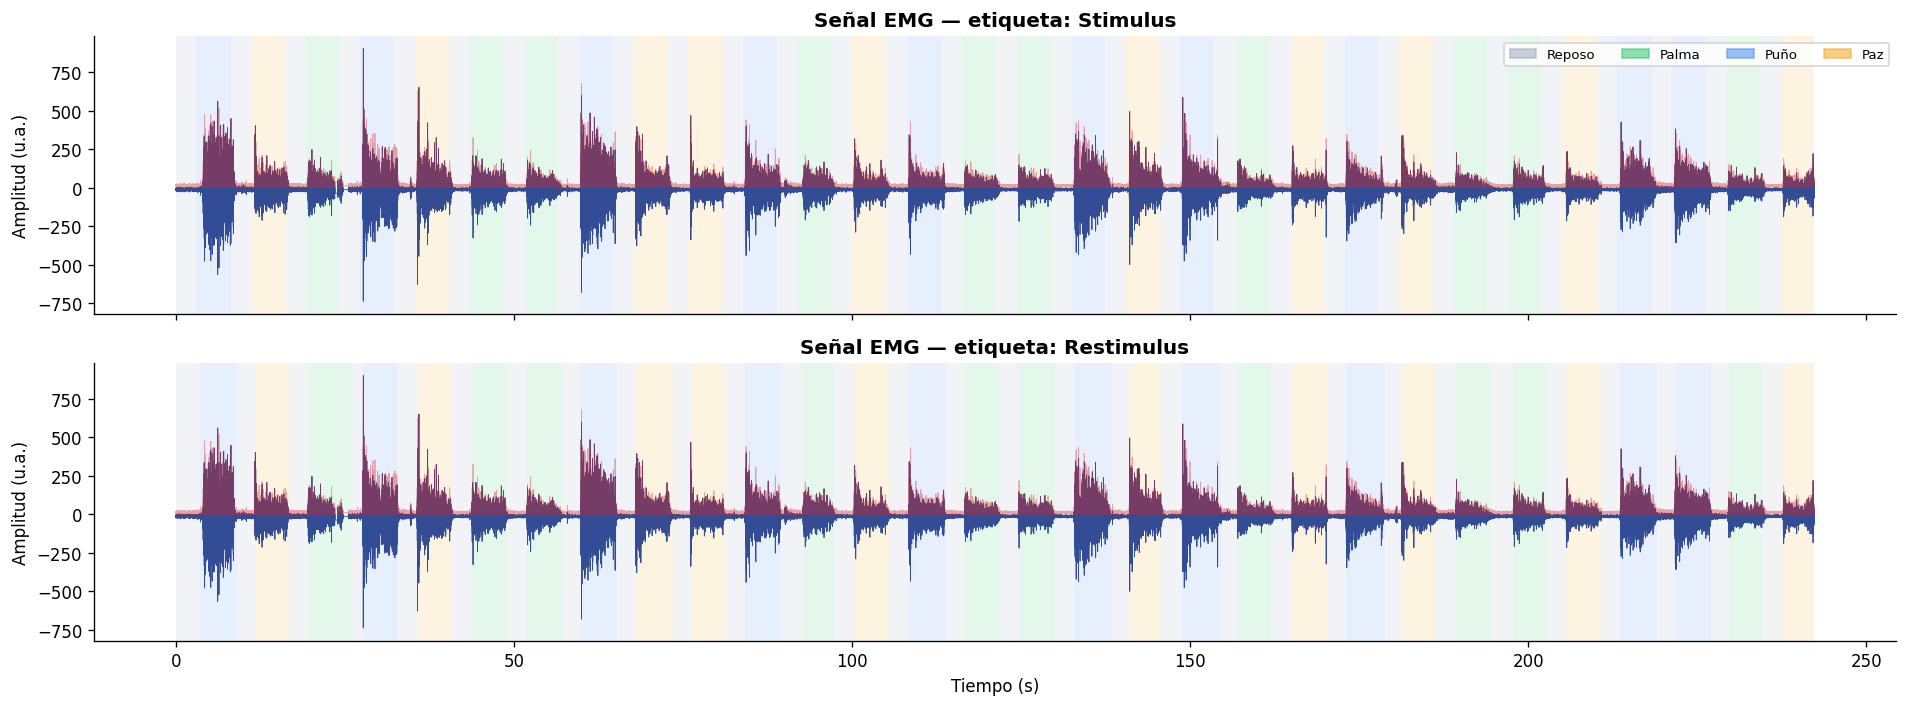

{
  "subject_id": "Sebe",
  "age": 23,
  "gender": "m",
  "laterality": "r",
  "forearm_circumference_cm": 26.0,
  "muscle": "fcpd",
  "date": "2026-04-26T22:26:02.673994",
  "fs_hz": 1000,
  "total_samples": 242160,
  "duration_s": 242.16,
  "gestures": [
    "palma",
    "puno",
    "paz"
  ],
  "gesture_ids": {
    "palma": 1,
    "puno": 2,
    "paz": 3
  },
  "n_sets": 10,
  "gesture_duration_s": 5.0,
  "rest_duration_s": 3.0,
  "prep_duration_s": 2.0,
  "randomized_order": true,
  "calibration": {
    "noise_mean": -2.912220229822397,
    "noise_std": 76.19257013736187,
    "onset_threshold_v": 225.6654901822632,
    "mvc_voltage_v": 172.64658021897253,
    "noise_samples": 5000,
    "mvc_samples": 3040
  },
  "onset_config": {
    "rms_window_ms": 100,
    "threshold_factor": 3.0,
    "min_active_ms": 200
  },
  "csv_file": "session_20260426_222602.csv"
}


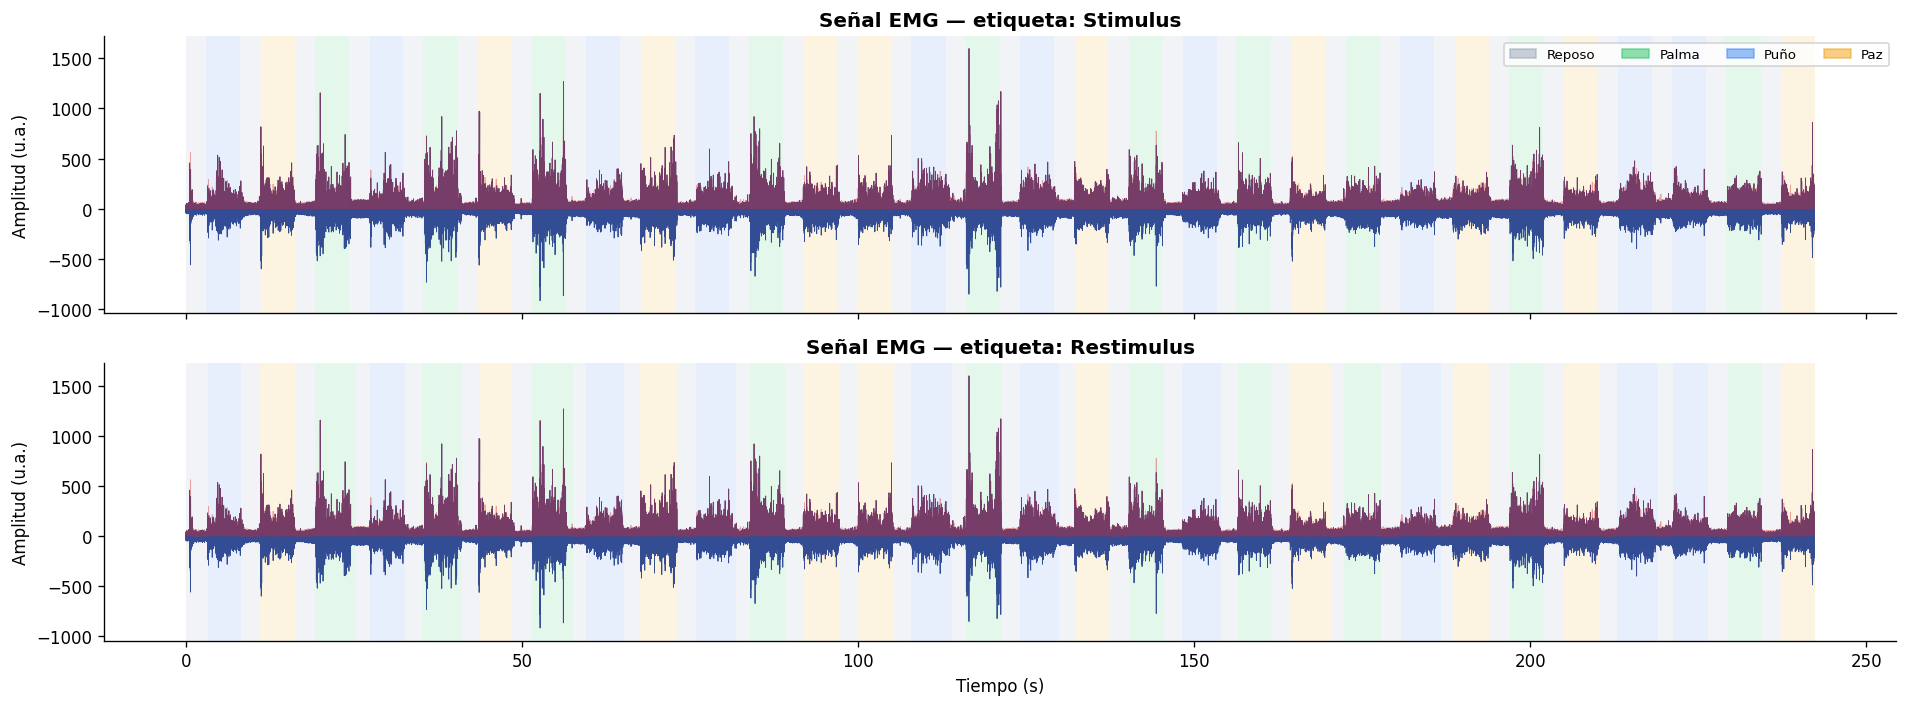

{
  "subject_id": "vale",
  "age": 23,
  "gender": "f",
  "laterality": "r",
  "forearm_circumference_cm": 23.5,
  "muscle": "fcpd",
  "date": "2026-05-15T19:39:36.735585",
  "fs_hz": 1000,
  "total_samples": 241840,
  "duration_s": 241.84,
  "gestures": [
    "palma",
    "puno",
    "paz"
  ],
  "gesture_ids": {
    "palma": 1,
    "puno": 2,
    "paz": 3
  },
  "n_sets": 10,
  "gesture_duration_s": 5.0,
  "rest_duration_s": 3.0,
  "prep_duration_s": 2.0,
  "randomized_order": true,
  "calibration": {
    "noise_mean": 14.559558426781003,
    "noise_std": 12.087120451619693,
    "onset_threshold_v": 50.82091978164008,
    "mvc_voltage_v": 171.38925355137076,
    "noise_samples": 5360,
    "mvc_samples": 3160
  },
  "onset_config": {
    "rms_window_ms": 100,
    "threshold_factor": 3.0,
    "min_active_ms": 200
  },
  "csv_file": "session_20260515_193936.csv"
}


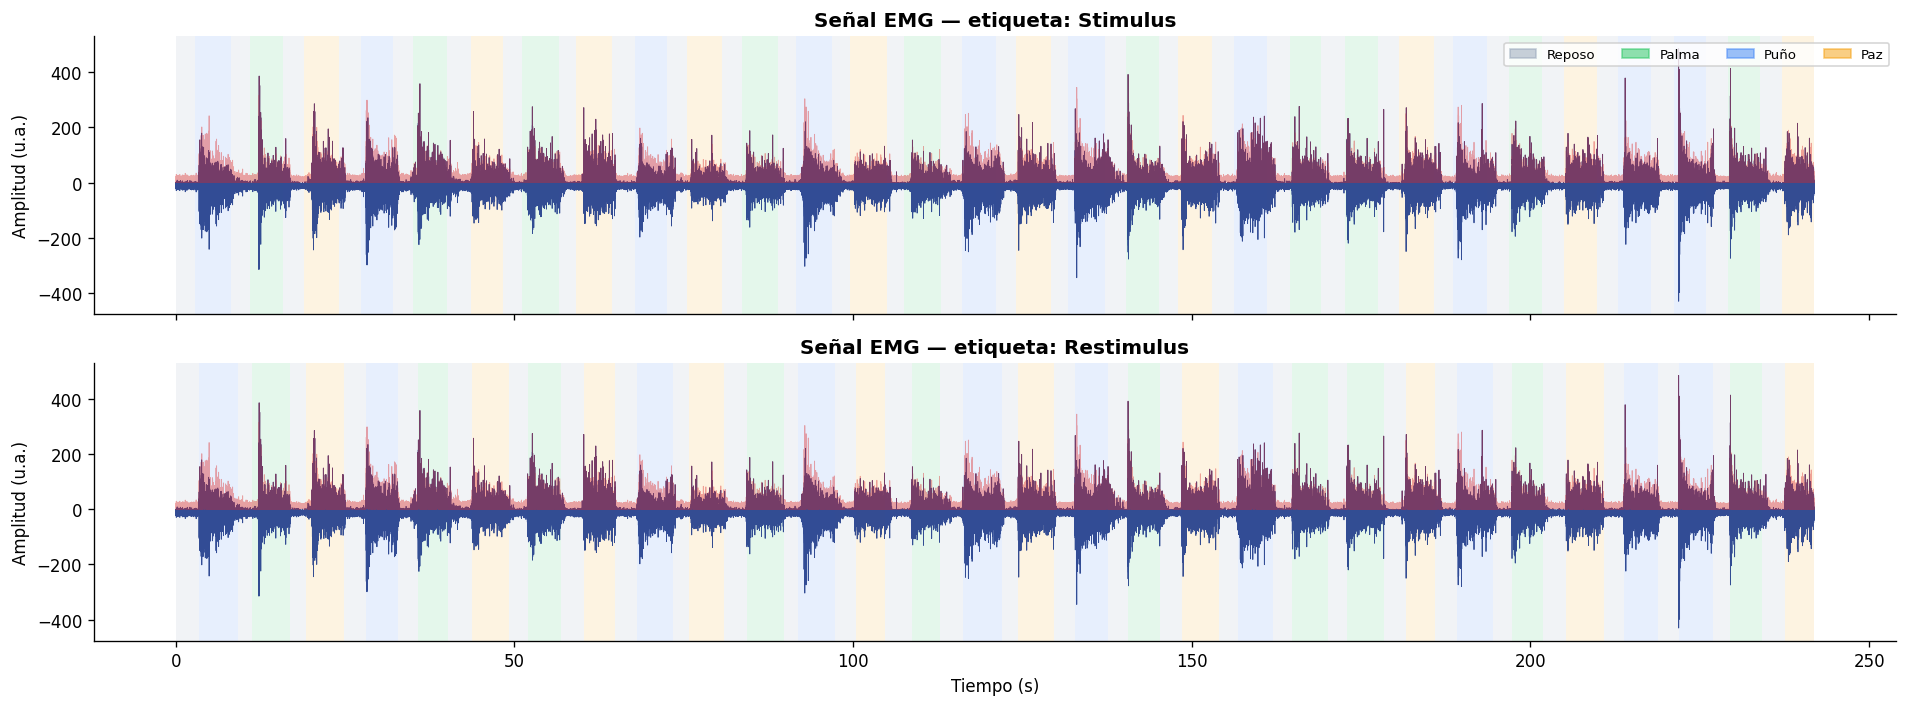

{
  "subject_id": "mai",
  "age": 57,
  "gender": "f",
  "laterality": "r",
  "forearm_circumference_cm": 25.5,
  "muscle": "fcpd",
  "date": "2026-05-15T19:55:16.186477",
  "fs_hz": 1000,
  "total_samples": 242680,
  "duration_s": 242.68,
  "gestures": [
    "palma",
    "puno",
    "paz"
  ],
  "gesture_ids": {
    "palma": 1,
    "puno": 2,
    "paz": 3
  },
  "n_sets": 10,
  "gesture_duration_s": 5.0,
  "rest_duration_s": 3.0,
  "prep_duration_s": 2.0,
  "randomized_order": true,
  "calibration": {
    "noise_mean": 15.365127327284654,
    "noise_std": 18.192497421890494,
    "onset_threshold_v": 69.94261959295613,
    "mvc_voltage_v": 229.89463400591936,
    "noise_samples": 5240,
    "mvc_samples": 2960
  },
  "onset_config": {
    "rms_window_ms": 100,
    "threshold_factor": 3.0,
    "min_active_ms": 200
  },
  "csv_file": "session_20260515_195516.csv"
}


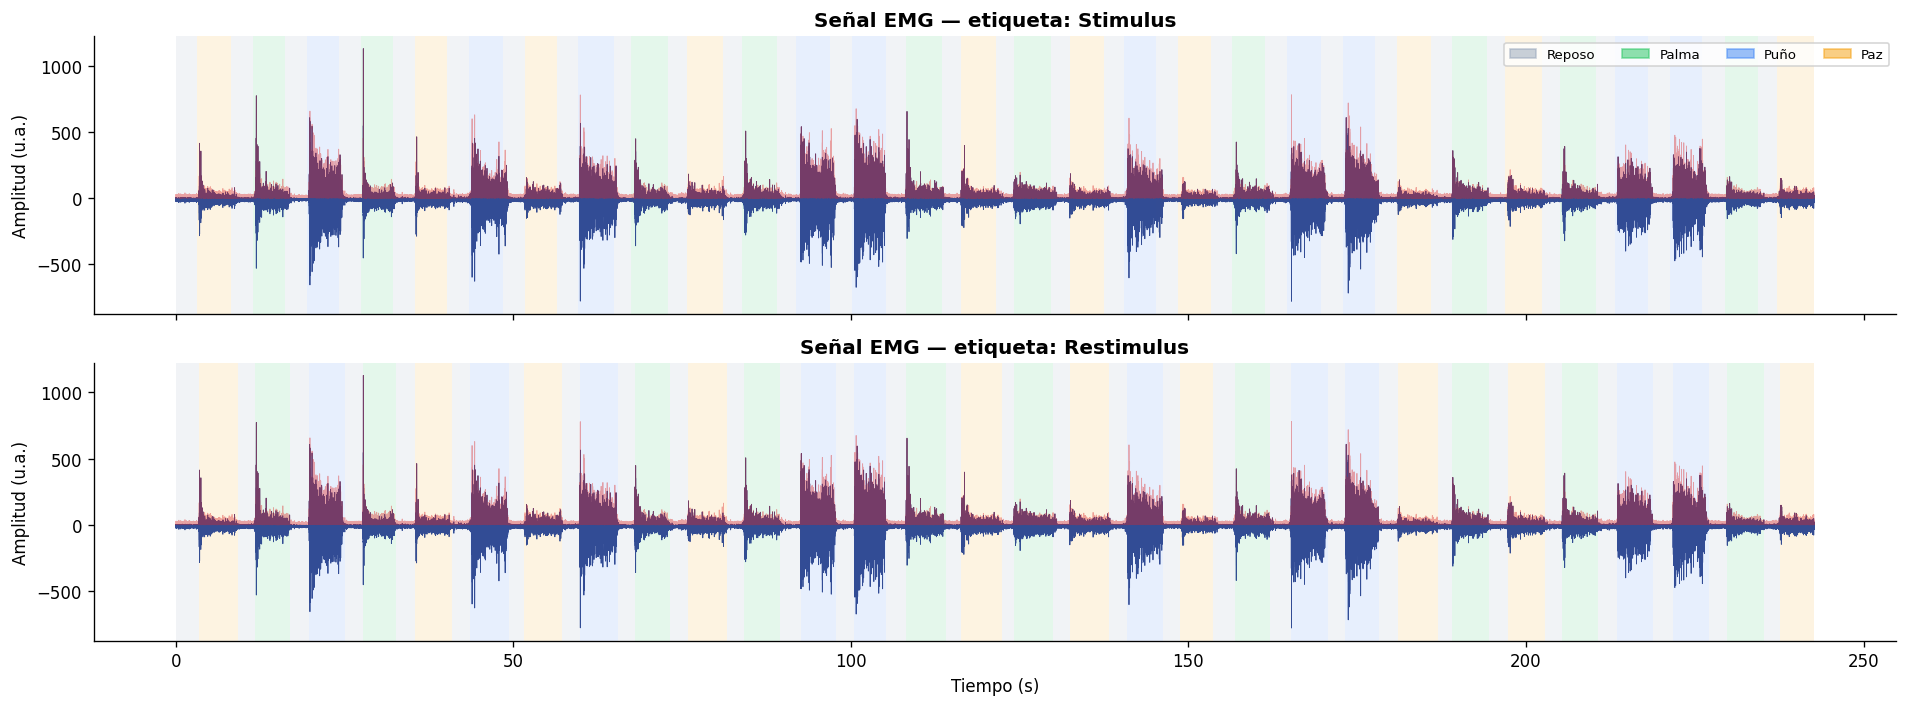

{
  "subject_id": "S10",
  "age": 52,
  "gender": "f",
  "laterality": "r",
  "forearm_circumference_cm": 23.5,
  "muscle": "fcpd",
  "date": "2026-05-15T22:11:19.359708",
  "fs_hz": 1000,
  "total_samples": 242200,
  "duration_s": 242.2,
  "gestures": [
    "palma",
    "puno",
    "paz"
  ],
  "gesture_ids": {
    "palma": 1,
    "puno": 2,
    "paz": 3
  },
  "n_sets": 10,
  "gesture_duration_s": 5.0,
  "rest_duration_s": 3.0,
  "prep_duration_s": 2.0,
  "randomized_order": true,
  "calibration": {
    "noise_mean": 15.877782899868535,
    "noise_std": 19.634811093212807,
    "onset_threshold_v": 74.78221617950696,
    "mvc_voltage_v": 172.26807827177691,
    "noise_samples": 4920,
    "mvc_samples": 3080
  },
  "onset_config": {
    "rms_window_ms": 100,
    "threshold_factor": 3.0,
    "min_active_ms": 200
  },
  "csv_file": "session_20260515_221119.csv"
}


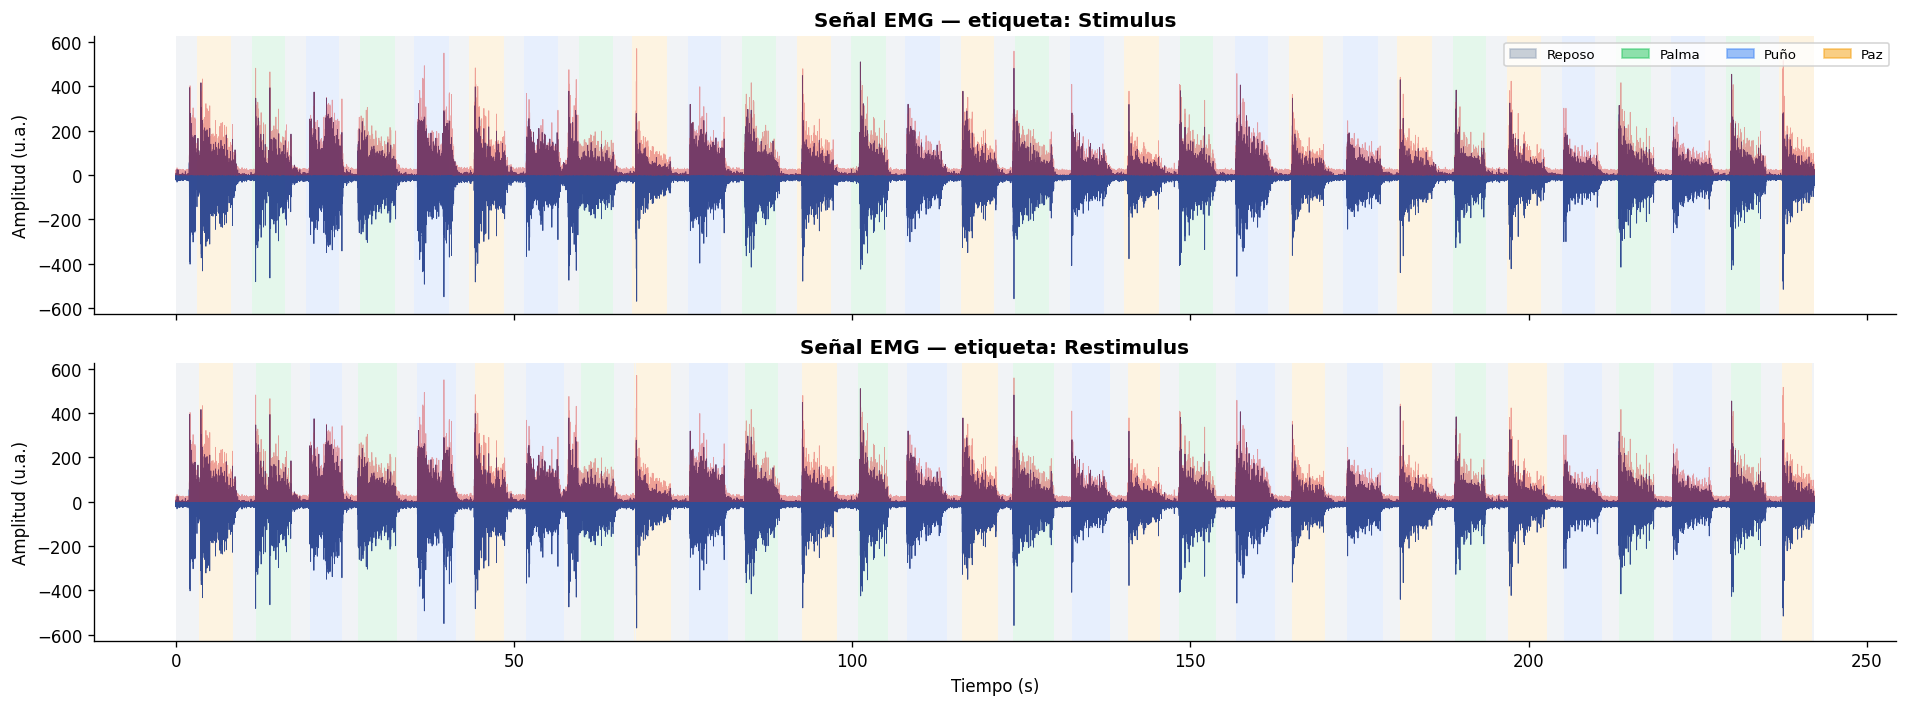

{
  "subject_id": "S11",
  "age": 12,
  "gender": "m",
  "laterality": "r",
  "forearm_circumference_cm": 22.0,
  "muscle": "fcpd",
  "date": "2026-05-15T22:27:18.456152",
  "fs_hz": 1000,
  "total_samples": 242400,
  "duration_s": 242.4,
  "gestures": [
    "palma",
    "puno",
    "paz"
  ],
  "gesture_ids": {
    "palma": 1,
    "puno": 2,
    "paz": 3
  },
  "n_sets": 10,
  "gesture_duration_s": 5.0,
  "rest_duration_s": 3.0,
  "prep_duration_s": 2.0,
  "randomized_order": true,
  "calibration": {
    "noise_mean": 14.66241061181898,
    "noise_std": 13.669120034707937,
    "onset_threshold_v": 55.66977071594279,
    "mvc_voltage_v": 213.9384724396863,
    "noise_samples": 5120,
    "mvc_samples": 3080
  },
  "onset_config": {
    "rms_window_ms": 100,
    "threshold_factor": 3.0,
    "min_active_ms": 200
  },
  "csv_file": "session_20260515_222718.csv"
}


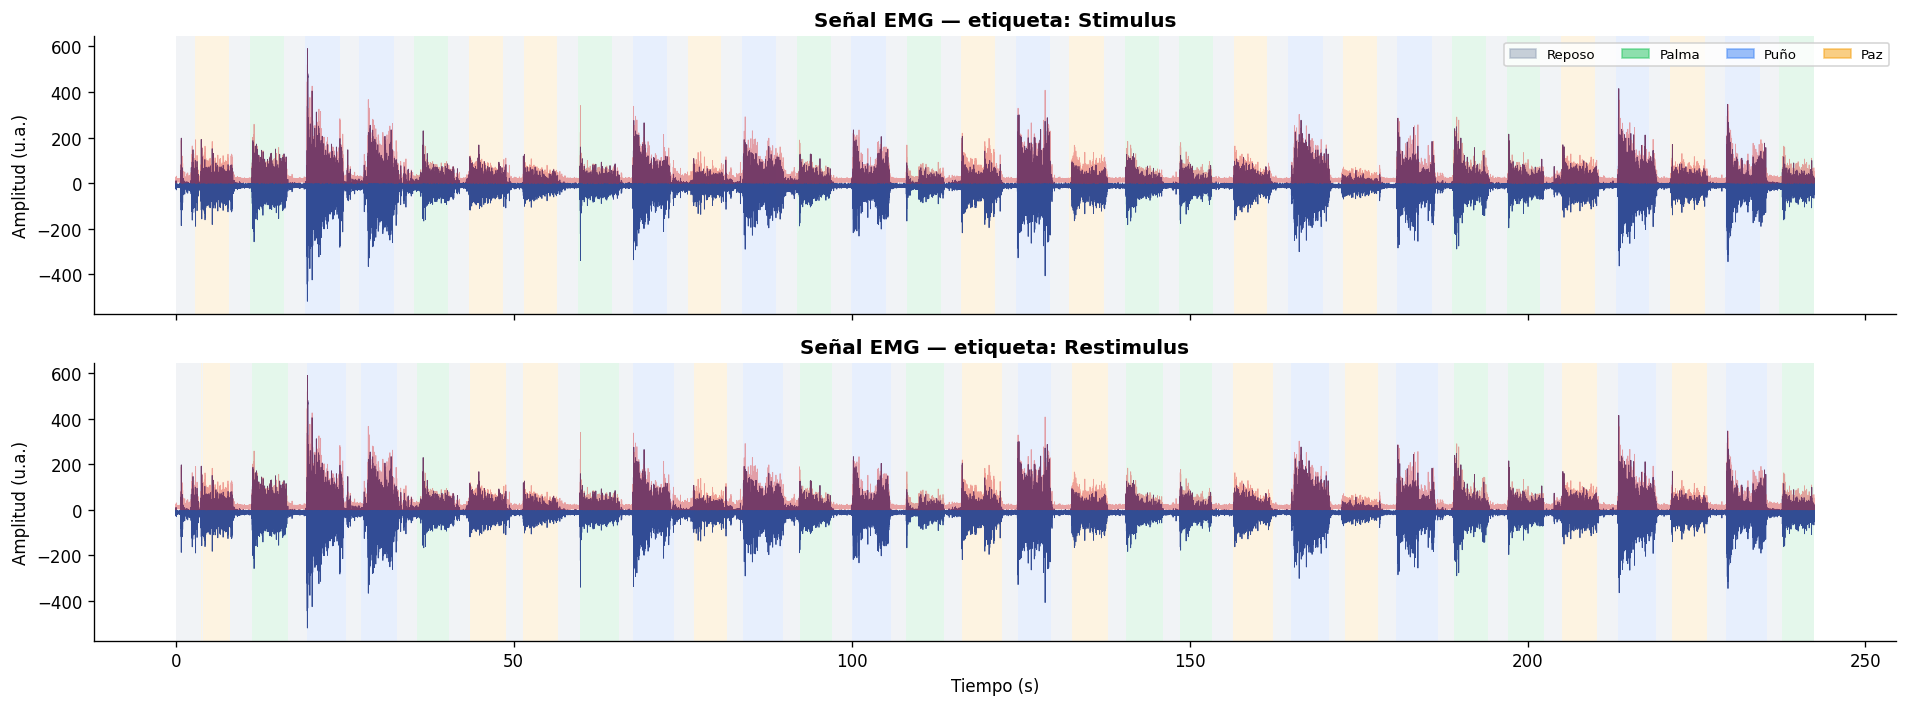

{
  "subject_id": "S12",
  "age": 48,
  "gender": "m",
  "laterality": "r",
  "forearm_circumference_cm": 28.5,
  "muscle": "fcpd",
  "date": "2026-05-15T22:42:08.529998",
  "fs_hz": 1000,
  "total_samples": 242400,
  "duration_s": 242.4,
  "gestures": [
    "palma",
    "puno",
    "paz"
  ],
  "gesture_ids": {
    "palma": 1,
    "puno": 2,
    "paz": 3
  },
  "n_sets": 10,
  "gesture_duration_s": 5.0,
  "rest_duration_s": 3.0,
  "prep_duration_s": 2.0,
  "randomized_order": true,
  "calibration": {
    "noise_mean": 17.82527640126693,
    "noise_std": 30.592975368932258,
    "onset_threshold_v": 109.60420250806371,
    "mvc_voltage_v": 348.260861495048,
    "noise_samples": 4920,
    "mvc_samples": 3080
  },
  "onset_config": {
    "rms_window_ms": 100,
    "threshold_factor": 3.0,
    "min_active_ms": 200
  },
  "csv_file": "session_20260515_224208.csv"
}


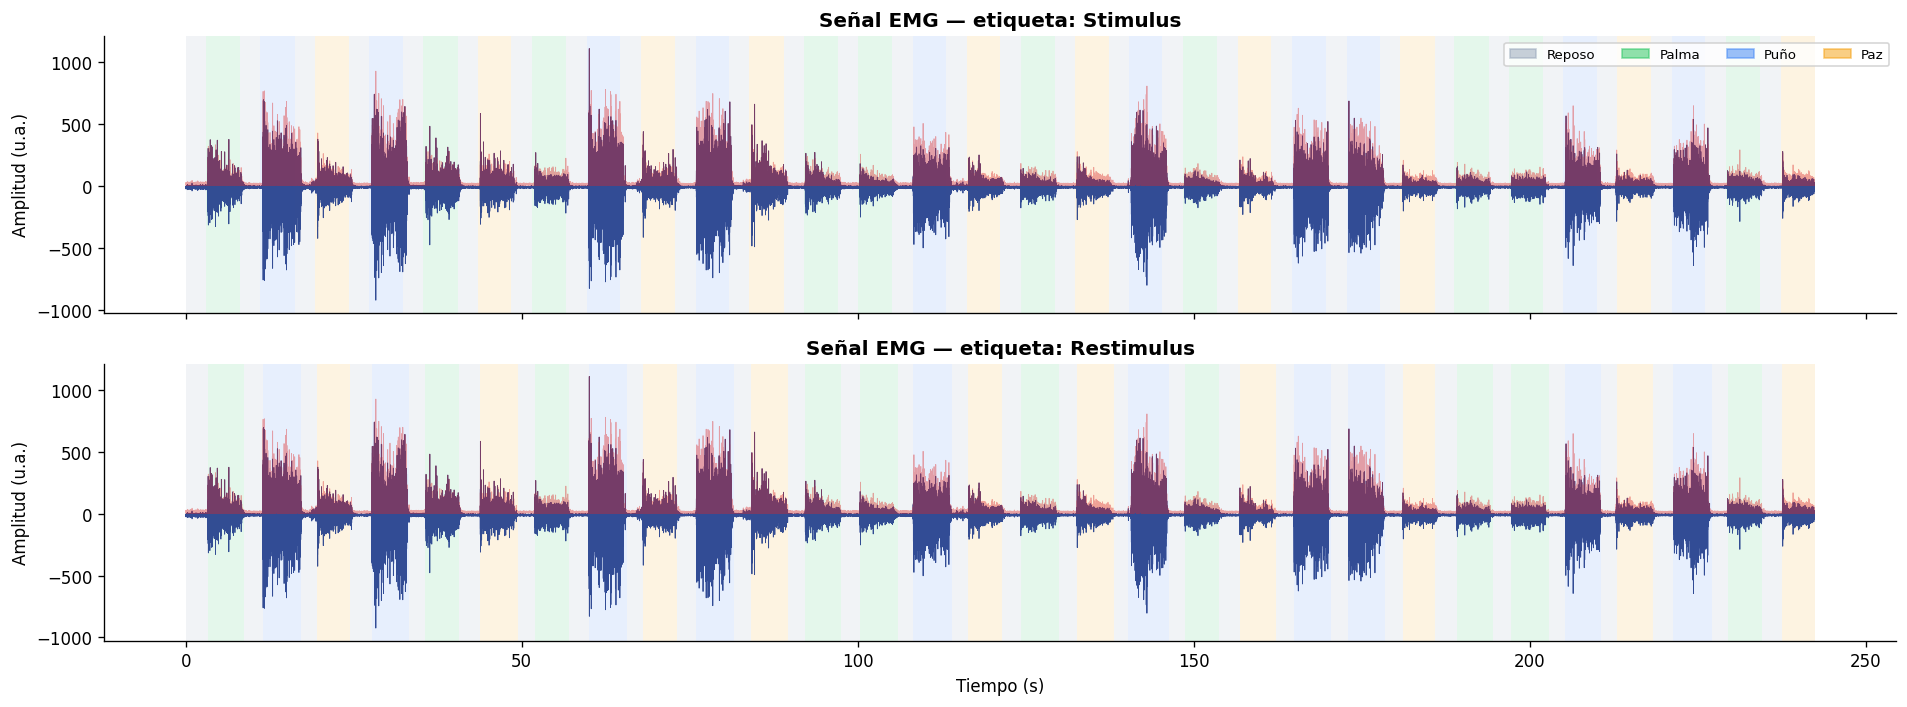

{
  "subject_id": "S13",
  "age": 24,
  "gender": "m",
  "laterality": "r",
  "forearm_circumference_cm": 29.0,
  "muscle": "fcpd",
  "date": "2026-05-15T22:50:44.346226",
  "fs_hz": 1000,
  "total_samples": 242280,
  "duration_s": 242.28,
  "gestures": [
    "palma",
    "puno",
    "paz"
  ],
  "gesture_ids": {
    "palma": 1,
    "puno": 2,
    "paz": 3
  },
  "n_sets": 10,
  "gesture_duration_s": 5.0,
  "rest_duration_s": 3.0,
  "prep_duration_s": 2.0,
  "randomized_order": true,
  "calibration": {
    "noise_mean": 17.986100390693593,
    "noise_std": 27.309215355428954,
    "onset_threshold_v": 99.91374645698045,
    "mvc_voltage_v": 408.2073018420805,
    "noise_samples": 4880,
    "mvc_samples": 3080
  },
  "onset_config": {
    "rms_window_ms": 100,
    "threshold_factor": 3.0,
    "min_active_ms": 200
  },
  "csv_file": "session_20260515_225044.csv"
}


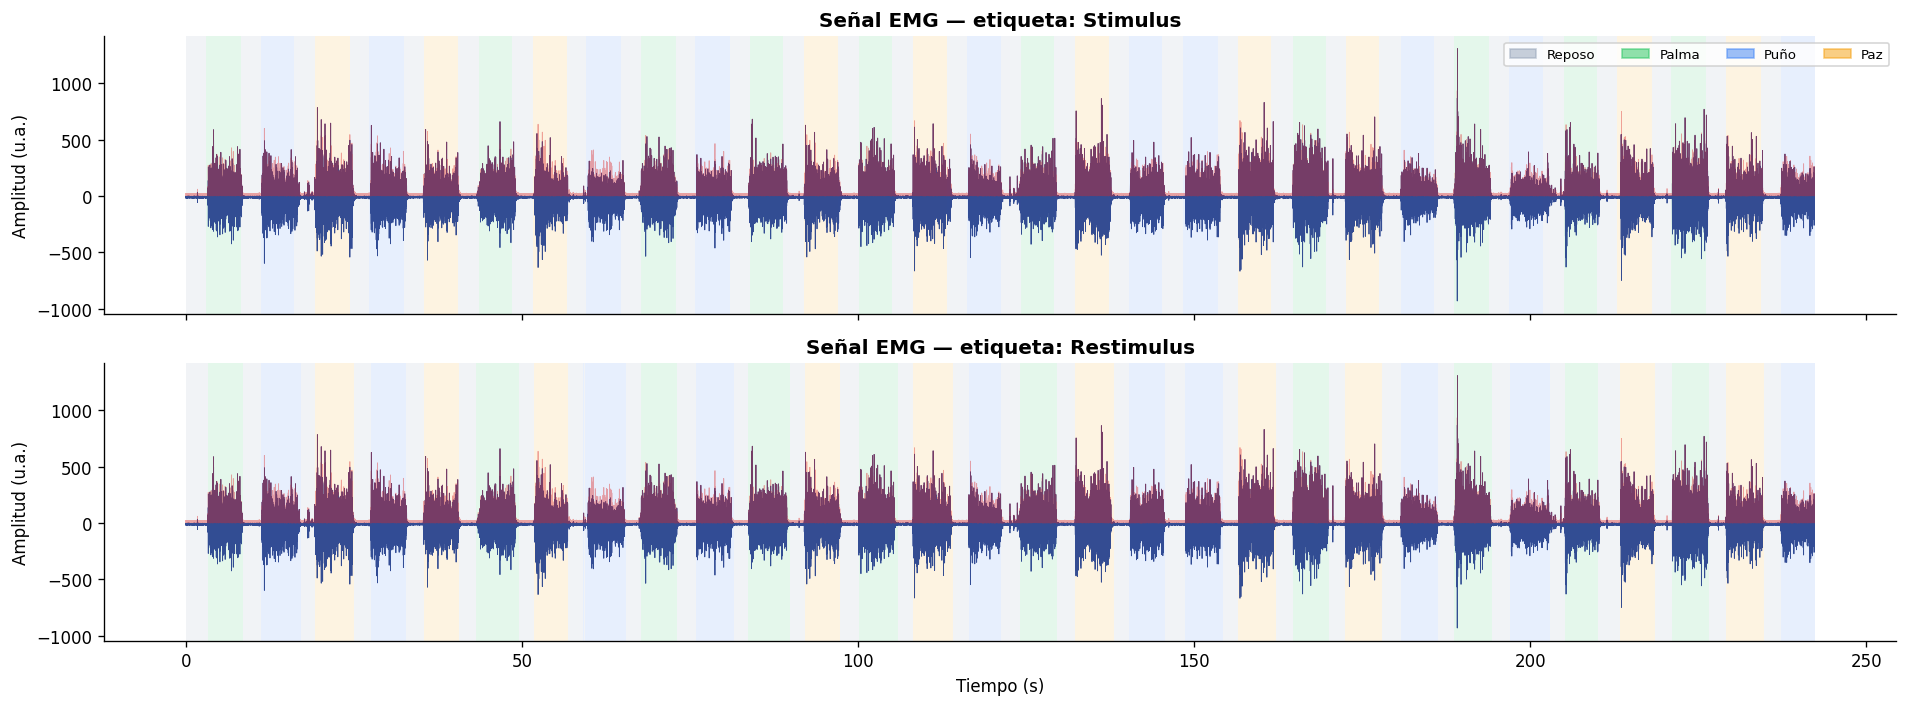

{
  "subject_id": "S14",
  "age": 23,
  "gender": "m",
  "laterality": "r",
  "forearm_circumference_cm": 27.5,
  "muscle": "fcpd",
  "date": "2026-05-15T23:03:36.964636",
  "fs_hz": 1000,
  "total_samples": 242200,
  "duration_s": 242.2,
  "gestures": [
    "palma",
    "puno",
    "paz"
  ],
  "gesture_ids": {
    "palma": 1,
    "puno": 2,
    "paz": 3
  },
  "n_sets": 10,
  "gesture_duration_s": 5.0,
  "rest_duration_s": 3.0,
  "prep_duration_s": 2.0,
  "randomized_order": true,
  "calibration": {
    "noise_mean": 15.698249157871592,
    "noise_std": 22.802657757459414,
    "onset_threshold_v": 84.10622243024983,
    "mvc_voltage_v": 352.0869782652969,
    "noise_samples": 4920,
    "mvc_samples": 3080
  },
  "onset_config": {
    "rms_window_ms": 100,
    "threshold_factor": 3.0,
    "min_active_ms": 200
  },
  "csv_file": "session_20260515_230336.csv"
}


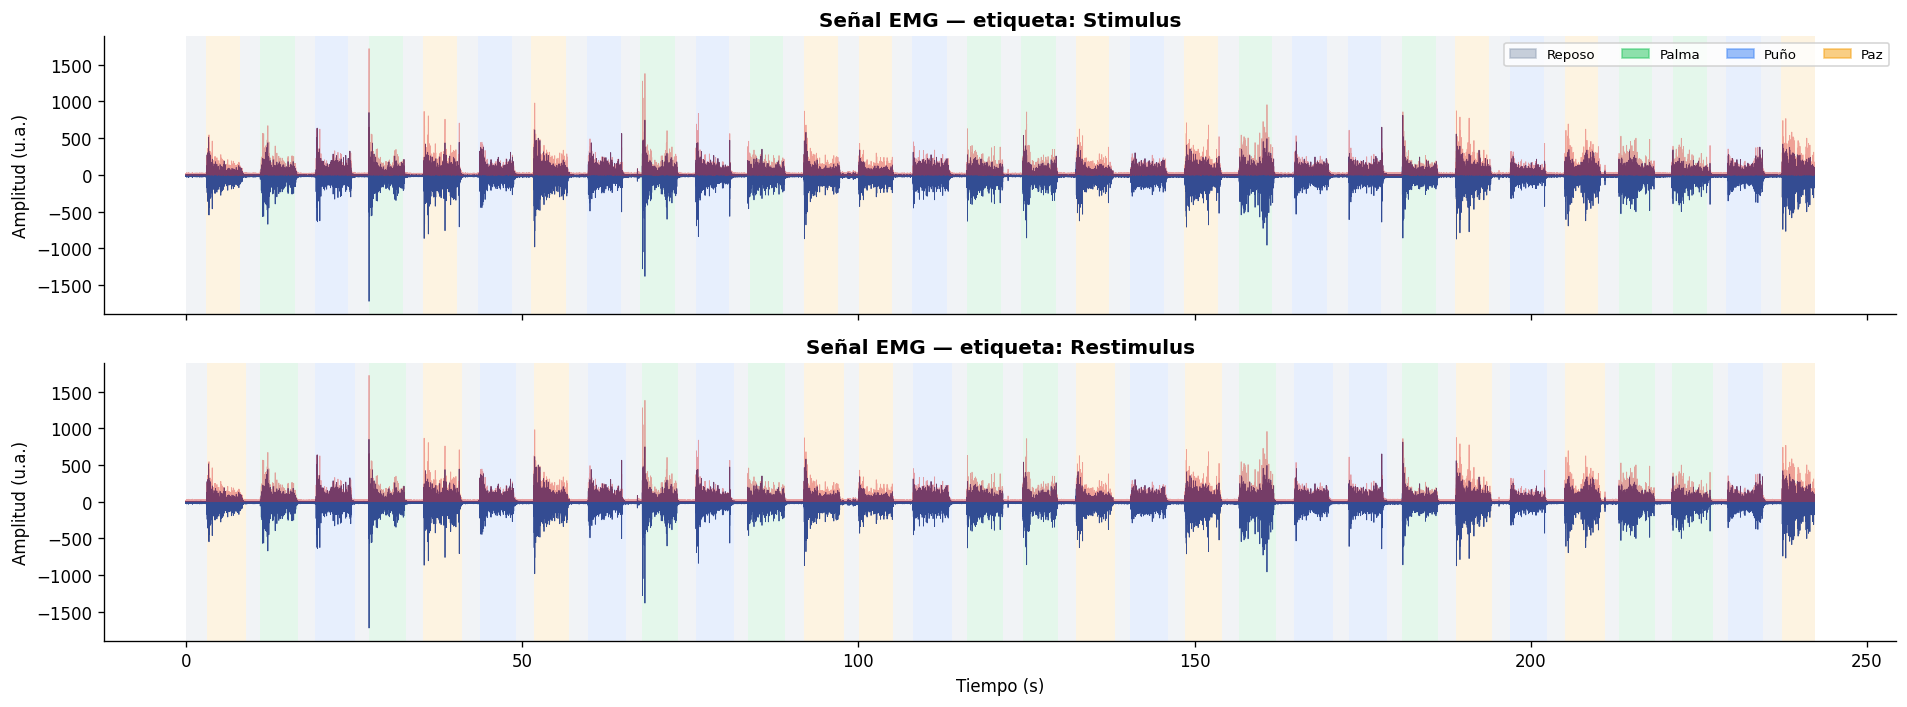

{
  "subject_id": "S15",
  "age": 24,
  "gender": "m",
  "laterality": "r",
  "forearm_circumference_cm": 30.5,
  "muscle": "fcdp",
  "date": "2026-05-15T23:15:13.383535",
  "fs_hz": 1000,
  "total_samples": 241840,
  "duration_s": 241.84,
  "gestures": [
    "palma",
    "puno",
    "paz"
  ],
  "gesture_ids": {
    "palma": 1,
    "puno": 2,
    "paz": 3
  },
  "n_sets": 10,
  "gesture_duration_s": 5.0,
  "rest_duration_s": 3.0,
  "prep_duration_s": 2.0,
  "randomized_order": true,
  "calibration": {
    "noise_mean": 12.830369083150986,
    "noise_std": 9.653131855251797,
    "onset_threshold_v": 41.78976464890638,
    "mvc_voltage_v": 201.9554264639215,
    "noise_samples": 5120,
    "mvc_samples": 3080
  },
  "onset_config": {
    "rms_window_ms": 100,
    "threshold_factor": 3.0,
    "min_active_ms": 200
  },
  "csv_file": "session_20260515_231513.csv"
}


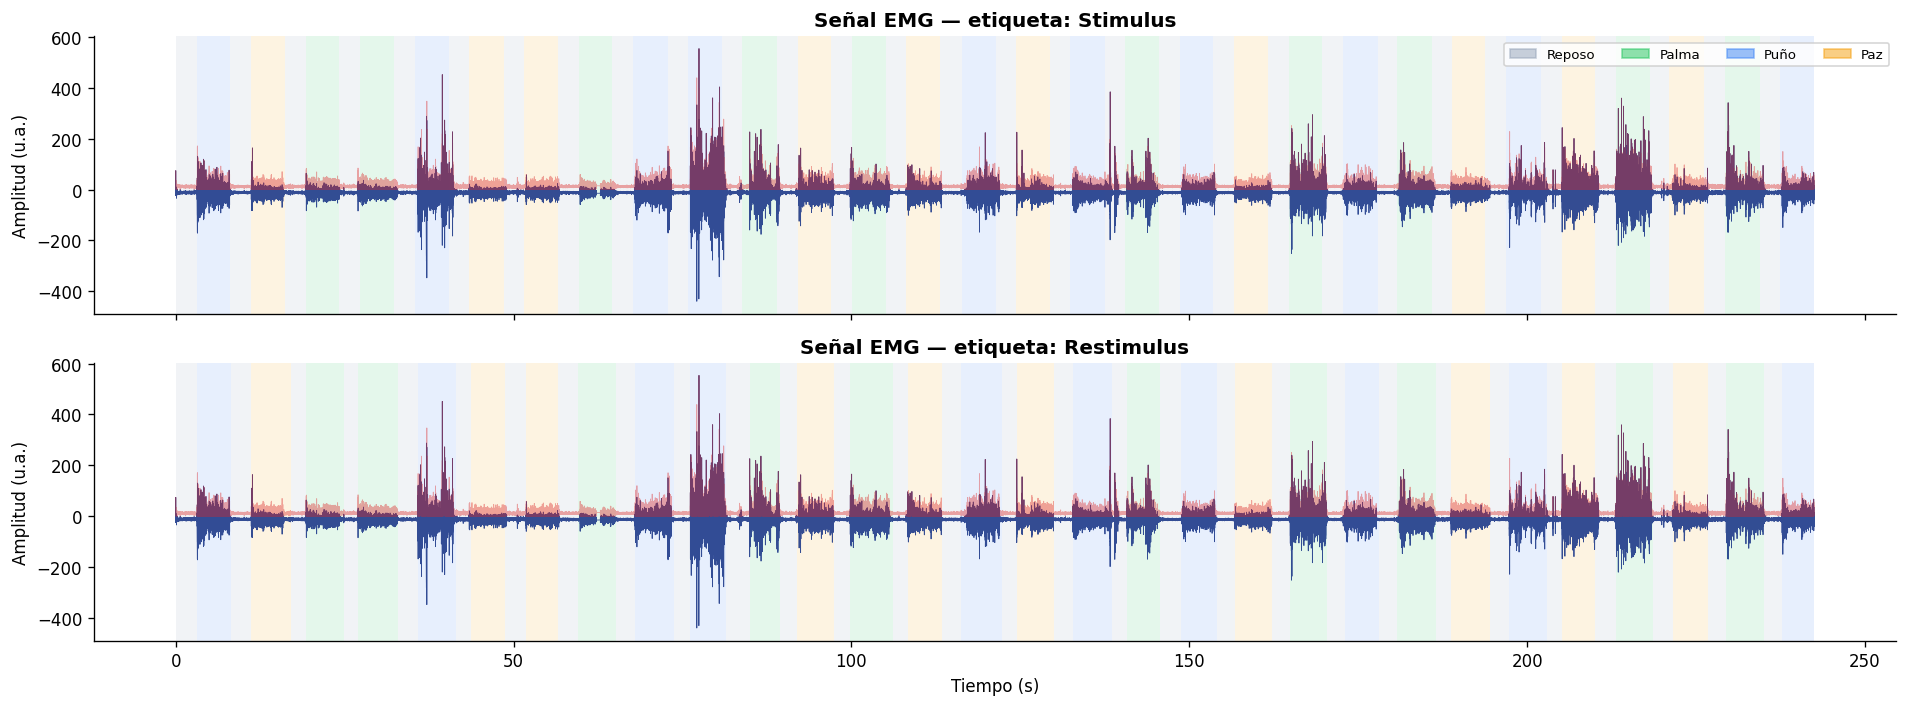

In [15]:
subjects = ["S02", "S07", "S08", "S09", "S10", "S11", "S12", "S13", "S14", "S15"]

for subject in subjects:
    csv_path = DATASETS[subject]["csv"]
    meta_path = DATASETS[subject]["meta"]

    with open(meta_path) as f:
        meta = json.load(f)
    print(json.dumps(meta, indent=2, ensure_ascii=False))

    # ── Dataset ────────────────────────────────────────────────────
    df = pd.read_csv(csv_path)
    df = df.sort_values("timestamp_us").reset_index(drop=True)
    df['time_s'] = (df['timestamp_us'] - df['timestamp_us'].iloc[0]) / 1e6

    fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

    for ax, col, title in zip(axes, ['stimulus', 'restimulus'], ['Stimulus', 'Restimulus']):
        # Señal EMG
        ax.plot(df['time_s'], df['filtered'], color='#1e3a8a', lw=0.5, alpha=0.9)
        ax.plot(df['time_s'], df['filtered'].abs(), color='#dc2626', lw=0.5, alpha=0.4, label='|filtrado|')

        # Fondo por gesto (segmentos contiguos)
        changes = df.index[df[col] != df[col].shift()].tolist() + [df.index[-1] + 1]
        for i in range(len(changes) - 1):
            i0, i1 = changes[i], changes[i+1]
            stim = df.loc[i0, col]
            t0 = df.loc[i0, 'time_s']
            t1 = df.loc[min(i1, df.index[-1]), 'time_s']
            ax.axvspan(t0, t1, alpha=0.12, color=STIM_COLORS[stim], lw=0)

        ax.set_ylabel('Amplitud (u.a.)')
        ax.set_title(f'Señal EMG — etiqueta: {title}', fontweight='bold')

    axes[-1].set_xlabel('Tiempo (s)')

    # Leyenda compartida
    patches = [mpatches.Patch(color=STIM_COLORS[k], alpha=0.5, label=STIM_NAMES[k])
            for k in STIM_COLORS]
    axes[0].legend(handles=patches, loc='upper right', fontsize=8, ncol=4)

    plt.tight_layout()
    plt.show()

## 4 — Zoom: Puño rep 1 + 3s de reposo
Ventana de 8 segundos: 5s de contracción + 3s de descanso.

In [16]:
# ── Extraer segmento: puño rep 1 (5s activo + 3s reposo) ──────
puno_r1 = df[(df['stimulus'] == 2) & (df['repetition'] == 1)]

if puno_r1.empty:
    print("[!] No se encontraron datos de puño rep 1 (stimulus=2, repetition=1)")
else:
    t0_us = puno_r1['timestamp_us'].iloc[0]
    t1_us = t0_us + 8_000_000  # 8 segundos

    seg = df[(df['timestamp_us'] >= t0_us) & (df['timestamp_us'] < t1_us)].copy()
    seg['t'] = (seg['timestamp_us'] - t0_us) / 1e6

    print(f"Muestras en segmento: {len(seg)}  ({len(seg)/1000:.1f}s)")
    print(f"  stimulus=2 (puño):  {(seg['stimulus']==2).sum()} muestras")
    print(f"  stimulus=0 (reposo):{(seg['stimulus']==0).sum()} muestras")

    # ── Gráfico ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 4))

    # Fondo: activo (azul) vs reposo (gris)
    ax.axvspan(0, 5, alpha=0.10, color=STIM_COLORS[2], lw=0, label='Activo (stimulus=2)')
    ax.axvspan(5, 8, alpha=0.10, color=STIM_COLORS[0], lw=0, label='Reposo (stimulus=0)')

    # Límite stimulus vs restimulus (+250ms)
    ax.axvline(0.25, color=STIM_COLORS[2], lw=1.2, ls='--', alpha=0.7, label='Restimulus inicio (+250ms)')
    ax.axvline(5 - 0.25, color=STIM_COLORS[0], lw=1.2, ls='--', alpha=0.7, label='Restimulus fin (-250ms)')
    ax.axvline(5.0, color='#475569', lw=1, ls='-', alpha=0.5)

    # Señal
    ax.plot(seg['t'], seg['filtered'], color='#1e3a8a', lw=0.8, alpha=0.9, label='EMG filtrado')

    # Envolvente (|filtrado|)
    ax.plot(seg['t'], seg['filtered'].abs(), color='#dc2626',
            lw=1.0, alpha=0.6, label='|EMG| (envolvente)')

    # Gaps: marcar con líneas verticales rojas
    dt_seg = seg['timestamp_us'].diff()
    gaps_seg = dt_seg[dt_seg > gap_threshold_us]
    for idx in gaps_seg.index:
        ax.axvline(seg.loc[idx, 't'], color='#f97316', lw=1, alpha=0.8)
    if len(gaps_seg) > 0:
        print(f"\nGaps en este segmento: {len(gaps_seg)}")
        for idx in gaps_seg.index:
            print(f"  {dt_seg[idx]/1000:.1f}ms en t={seg.loc[idx,'t']:.3f}s")

    ax.set_xlabel('Tiempo relativo (s)')
    ax.set_ylabel('Amplitud (u.a.)')
    ax.set_title('PUÑO — Repetición 1  |  5s activo + 3s reposo', fontweight='bold')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.set_xlim(0, 8)

    # Etiquetas de texto
    y_top = ax.get_ylim()[1]
    ax.text(2.5, y_top * 0.92, 'CIERRA EL PUÑO', ha='center', color=STIM_COLORS[2],
            fontsize=10, fontweight='bold')
    ax.text(6.5, y_top * 0.92, 'DESCANSA', ha='center', color='#475569',
            fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

KeyError: 'repetition'